In [1]:
#1. Ler dados do CSV
#Ler os dados de um arquivo CSV e imprimir na tela
import pandas as pd

df = pd.read_csv('leituras_padronizadas_imputed.csv')

# Converter para datetime e definir índice
df['timestamp_group'] = pd.to_datetime(df['timestamp_group'])
df = df.set_index('timestamp_group')
# Garantir a ordem cronológica
df = df.sort_index()

# Selecionar colunas específicas (Inicialmente as colunas que possuem dados completos)
colunas_para_manter = [
    'LIC_22311020', 
    'LIC_22311020.ES', 
    'LIC_22311020.MV', 
    'LIC_22311020.SV', 
    'target'
]

df_limpo = df[colunas_para_manter]

df_limpo

,LIC_22311020,LIC_22311020.ES,LIC_22311020.MV,LIC_22311020.SV,target
timestamp_group,,,,,
2015-10-15 10:25:46.336456,59.877106,1.0,30.072546,60.0,1.0
2015-10-15 11:54:43.259002,60.173992,1.0,29.919247,60.0,1.0
2015-10-15 12:36:48.879013,59.976227,1.0,31.306858,60.0,1.0
2015-10-15 13:22:52.749008,60.562874,1.0,32.694470,60.0,1.0
2015-10-15 14:09:17.128005,59.914288,1.0,34.440201,60.0,1.0
...,...,...,...,...,...
2025-10-15 07:33:18.358001,54.829937,1.0,22.852071,55.0,0.0
2025-10-15 08:03:43.641006,54.829937,1.0,24.470030,55.0,0.0
2025-10-15 08:44:53.295013,54.829937,1.0,26.087990,55.0,0.0


In [2]:
#2. Engenharia de Features Temporais
# 2.1. Features de Lag (Atraso) valor do sensor X minutos atrás
# 2.2. Features de Janela Móvel (Rolling Window) média, desvio padrão, min, max do sensor nos últimos Y minutos

# Snippet de exemplo para esta etapa
df_features = df_limpo.copy()

# Vamos pegar todas as colunas de sensores (tudo, exceto 'target')
variaveis_sensores = [col for col in df_limpo.columns if col != 'target']

# PERÍODOS BASEADOS EM NÚMERO DE LINHAS (amostras)
# Em vez de '5T' (5 minutos), usamos '5' (5 linhas)
# Vamos usar as 5, 10 e 20 amostras anteriores para criar features.
periodos_janela_int = [5, 10, 20] 

print("Iniciando Engenharia de Features...")
for sensor in variaveis_sensores:
    for n_rows in periodos_janela_int:
        
        # Criar Lags (valor N linhas atrás)
        df_features[f'{sensor}_lag_{n_rows}'] = df_features[sensor].shift(n_rows)
        
        # Criar Média Móvel (baseada nas N linhas anteriores)
        df_features[f'{sensor}_roll_mean_{n_rows}'] = df_features[sensor].rolling(window=n_rows).mean()
        
        # Criar Desvio Padrão Móvel
        df_features[f'{sensor}_roll_std_{n_rows}'] = df_features[sensor].rolling(window=n_rows).std()

print("Engenharia de Features concluída.")

Iniciando Engenharia de Features...
Engenharia de Features concluída.


In [3]:
#3. Preparação Final
# 3.1. Remover NaNs
# 3.2. Definir X e y

# Snippet de exemplo para esta etapa

# 1. Remover NaNs criados pela engenharia de features
df_final = df_features.dropna()

# 2. Definir X e y
y = df_final['target']
X = df_final.drop('target', axis=1)

In [4]:
#4. Divisão de Treino e Teste
# Os dados deverão seguir ordem cronológica

# Snippet de exemplo para esta etapa
tamanho_teste_percent = 0.20 # Usar 20% dos dados para teste
tamanho_teste_idx = int(len(X) * (1 - tamanho_teste_percent))

X_train, X_test = X.iloc[:tamanho_teste_idx], X.iloc[tamanho_teste_idx:]
y_train, y_test = y.iloc[:tamanho_teste_idx], y.iloc[tamanho_teste_idx:]

print(f"Tamanho Treino: {len(X_train)} amostras")
print(f"Tamanho Teste:  {len(X_test)} amostras")

Tamanho Treino: 86652 amostras
Tamanho Teste:  21663 amostras


In [5]:
#5
from xgboost import XGBClassifier

# Calcular o scale_pos_weight (MUITO IMPORTANTE para dados desbalanceados)
contagem_0 = y_train.value_counts()[0.0]
contagem_1 = y_train.value_counts()[1.0]
escala = contagem_0 / contagem_1 
print(f"Usando scale_pos_weight: {escala:.2f}")

# Instanciar o modelo de CLASSIFICAÇÃO
xgb_class = XGBClassifier(
    n_estimators=100,      
    learning_rate=0.1,
    objective='binary:logistic', # Objetivo de classificação
    scale_pos_weight=escala,     # Parâmetro para desbalanceamento
    use_label_encoder=False,
    eval_metric='logloss'        
)

# Treinar o modelo
xgb_class.fit(X_train, y_train)

Usando scale_pos_weight: 2.93


c:\dev\tcc\planejamento_manutencao_ml\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:18:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Acurácia: 0.8332179291880164

Matriz de Confusão:
[[18010  1405]
 [ 2208    40]]


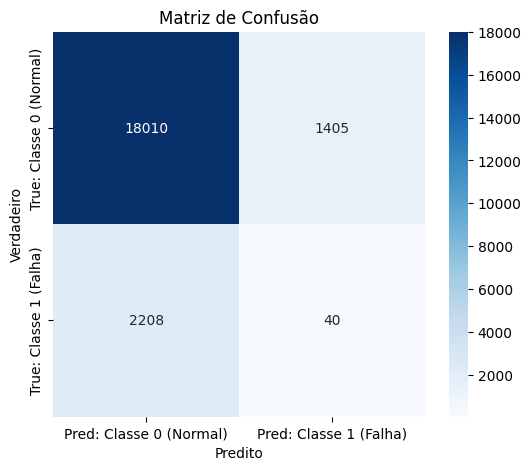


Relatório de Classificação:
                   precision    recall  f1-score   support

Classe 0 (Normal)       0.89      0.93      0.91     19415
 Classe 1 (Falha)       0.03      0.02      0.02      2248

         accuracy                           0.83     21663
        macro avg       0.46      0.47      0.47     21663
     weighted avg       0.80      0.83      0.82     21663



In [10]:
#6 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Fazer previsões nos dados de teste
y_pred = xgb_class.predict(X_test)

# Avaliar
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusão:")
# Mostrar matriz de confusão como gráfico
cm = confusion_matrix(y_test, y_pred)
print(cm)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Classe 0 (Normal)', 'Pred: Classe 1 (Falha)'],
            yticklabels=['True: Classe 0 (Normal)', 'True: Classe 1 (Falha)'])
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.title('Matriz de Confusão')
plt.show()
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Classe 0 (Normal)', 'Classe 1 (Falha)']))